# MNIST Convolutional Neural Network

## Objective

In this notebook, we will build a convolutional neural network (CNN) for MNIST digit classification.

The previous baseline model treated each image as a flattened vector of 784 pixel values.

A CNN allows the model to learn local spatial features and combine them into increasingly complex representations.

## Goals

1. Build a CNN architecture
2. Understand convolution and pooling
3. Train the model
4. Evaluate its performance
5. Compare it against the fully connected baseline
6. Analyze whether the CNN improves the types of errors observed previously

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as py
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cpu


In [5]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="../../data/raw",
    train=True,
    download=True,
    transform = transform
)

test_dataset = torchvision.datasets.MNIST(
    root="../../data/raw",
    train=False,
    download=True,
    transform = transform
)

In [8]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle=False
)

images, labels = next(iter(train_loader))
print("Images: ", images.shape)
print("Labels: ", labels.shape)

Images:  torch.Size([64, 1, 28, 28])
Labels:  torch.Size([64])


In [12]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels = 1,
                out_channels = 32,
                kernel_size = 3,
                padding = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2),
            nn.Conv2d(
                in_channels = 32,
                out_channels = 64,
                kernel_size = 3,
                padding = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
model = CNNModel().to(device)

print(model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=10, bias=True)
  )
)


In [15]:
images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    features = model.features(images)

print("Input :", images.shape)
print("Features :", features.shape)

Input : torch.Size([64, 1, 28, 28])
Features : torch.Size([64, 64, 7, 7])


In [16]:
with torch.no_grad():
    outputs = model(images)

print("Output: ", outputs.shape)

Output:  torch.Size([64, 10])


In [20]:
total_params = sum(
    parameter.numel() for parameter in model.parameters()
)
print(f"Total parameters: {total_params}")

Total parameters: 50186


First, we will initially use the same loss function and optimizer as the baseline model to make the comparison reasonably clean 

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [22]:
epochs = 5

train_losses = []

for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.4f}")

Epoch 1/5 - Loss: 0.1819
Epoch 2/5 - Loss: 0.0554
Epoch 3/5 - Loss: 0.0410
Epoch 4/5 - Loss: 0.0339
Epoch 5/5 - Loss: 0.0265


([<matplotlib.axis.XTick at 0x19e6ac679e0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

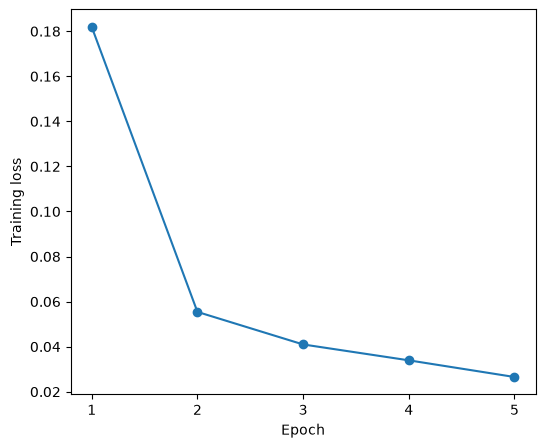

In [23]:
plt.figure(figsize = (6, 5))

plt.plot(
    range(1, epochs+1),
    train_losses,
    marker = "o"
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.xticks(range(1, epochs + 1))

In [26]:
def evaluate(model, dataloader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim = 1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    return correct / total

In [27]:
test_accuracy = evaluate(
    model = model,
    dataloader = test_loader,
    device = device
)

print(f"Test accuracy: {test_accuracy:.2%}")

Test accuracy: 98.89%


# Initial CNN Results

The initial CNN achieved a test accuracy of **98.89%** after 5 epochs.

Compared with the fully connected baseline:

| Model | Parameters | Test Accuracy |
|---|---:|---:|
| Fully Connected Baseline | 101,770 | 97.04% |
| CNN | 50,186 | 98.89% |

The CNN uses approximately half as many trainable parameters while achieving substantially higher test accuracy.

The improvement is consistent with the CNN's ability to exploit the spatial structure of images through convolutional filters and local receptive fields.

However, accuracy alone does not explain how the CNN differs from the baseline. We will therefore perform the same error analysis on the CNN before making architectural or hyperparameter changes.